# Boston Housing - Complete Machine Learning Analysis

***Target variable*** : MEDV (Median home value in $1000s)

***Models***          : Linear Regression, Ridge, Lasso, Random Forest, Gradient Boosting

***Steps*** :     EDA → Preprocessing → Training → Evaluation → Feature Importance → Visualisation

## Dataset Description

The Boston Housing Dataset

The Boston Housing Dataset is a derived from information collected by the U.S. Census Service concerning housing in the area of Boston MA. The following describes the dataset columns:

- CRIM - per capita crime rate by town
- ZN - proportion of residential land zoned for lots over 25,000 sq.ft.
- INDUS - proportion of non-retail business acres per town.
- CHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)
- NOX - nitric oxides concentration (parts per 10 million)
- RM - average number of rooms per dwelling
- AGE - proportion of owner-occupied units built prior to 1940
- DIS - weighted distances to five Boston employment centres
- RAD - index of accessibility to radial highways
- TAX - full-value property-tax rate per ($10,000)

# Import Libraries and Dataset

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
df = pd.read_csv('/Users/festusattornelson/Documents/Projects/Python MSIT/Boston_Housing/boston_housing.csv')
df.head(5)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [3]:
df.isna().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
LSTAT      0
MEDV       0
dtype: int64

In [4]:
df.shape

(506, 13)

In [5]:
df = df.rename(columns={
    "CRIM": "crime_town",
    "ZN": "land_zones",
    "INDUS": "non_retail_business",
    "CHAS": "river_dummy",
    "NOX": "nitric_oxide_conc",
    "RM": "avg_rooms_dwelling",
    "DIS": "dist_emp_centres",
    "RAD": "highway_accessibility",
     "PTRATIO": "pupil_teacher",
    "LSTAT": "lower_pop_status"
})

In [6]:
df.columns

Index(['crime_town', 'land_zones', 'non_retail_business', 'river_dummy',
       'nitric_oxide_conc', 'avg_rooms_dwelling', 'AGE', 'dist_emp_centres',
       'highway_accessibility', 'TAX', 'pupil_teacher', 'lower_pop_status',
       'MEDV'],
      dtype='object')

# Exploratory Data Analysis (EDA)

In [7]:
df.describe().round(2)

,crime_town,land_zones,non_retail_business,river_dummy,nitric_oxide_conc,avg_rooms_dwelling,AGE,dist_emp_centres,highway_accessibility,TAX,pupil_teacher,lower_pop_status,MEDV
count,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00
mean,3.61,11.36,11.14,0.07,0.55,6.28,68.57,3.80,9.55,408.24,18.46,12.65,22.53
std,8.60,23.32,6.86,0.25,0.12,0.70,28.15,2.11,8.71,168.54,2.16,7.14,9.20
min,0.01,0.00,0.46,0.00,0.38,3.56,2.90,1.13,1.00,187.00,12.60,1.73,5.00
25%,0.08,0.00,5.19,0.00,0.45,5.89,45.02,2.10,4.00,279.00,17.40,6.95,17.02
50%,0.26,0.00,9.69,0.00,0.54,6.21,77.50,3.21,5.00,330.00,19.05,11.36,21.20
75%,3.68,12.50,18.10,0.00,0.62,6.62,94.07,5.19,24.00,666.00,20.20,16.96,25.00
max,88.98,100.00,27.74,1.00,0.87,8.78,100.00,12.13,24.00,711.00,22.00,37.97,50.00


In [8]:
#df.info()

***Figure 1: fDistribution of target variable***

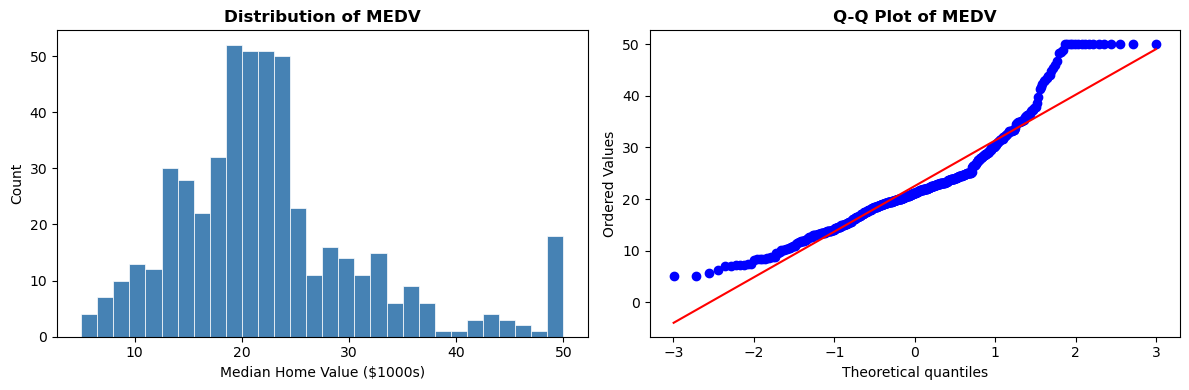

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
axes[0].hist(df['MEDV'], bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].set_title('Distribution of MEDV', fontweight='bold')
axes[0].set_xlabel('Median Home Value ($1000s)')
axes[0].set_ylabel('Count')
 
# Q-Q style: sorted MEDV vs normal quantiles
from scipy import stats
stats.probplot(df['MEDV'], plot=axes[1])
axes[1].set_title('Q-Q Plot of MEDV', fontweight='bold')
 
plt.tight_layout()
plt.savefig('01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

***Figure 2: Correlation heatmap***

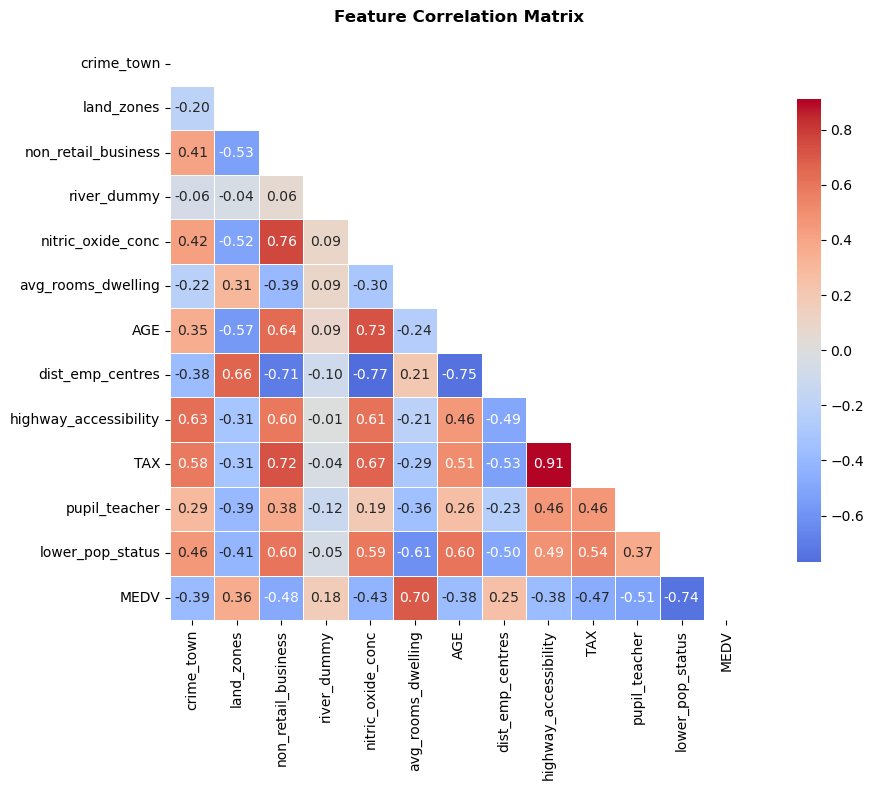

In [12]:
plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(df.corr(), dtype=bool))
sns.heatmap(df.corr(), mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontweight='bold', pad=14)
plt.tight_layout()
#plt.savefig('02_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

***Figure 3: Key feature scatter plots***

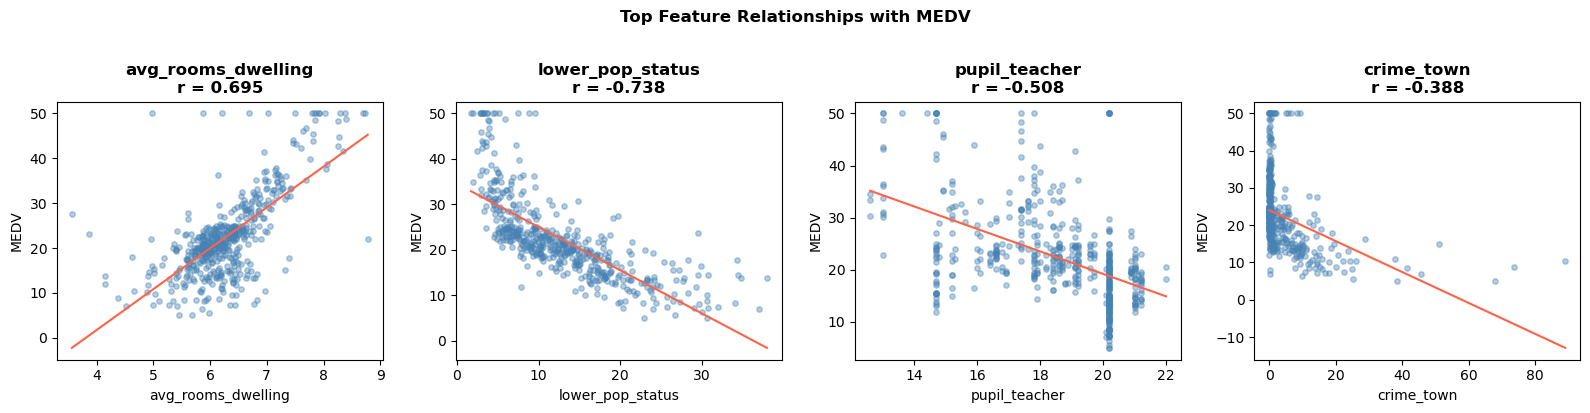

In [14]:
top_features = ['avg_rooms_dwelling', 'lower_pop_status', 'pupil_teacher', 'crime_town']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
 
for ax, feat in zip(axes, top_features):
    ax.scatter(df[feat], df['MEDV'], alpha=0.4, s=15, color='steelblue')
    m, b = np.polyfit(df[feat], df['MEDV'], 1)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    ax.plot(x_line, m * x_line + b, color='tomato', linewidth=1.5)
    corr_val = df[feat].corr(df['MEDV'])
    ax.set_title(f'{feat}\nr = {corr_val:.3f}', fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('MEDV')
 
plt.suptitle('Top Feature Relationships with MEDV', fontweight='bold', y=1.02)
plt.tight_layout()
#plt.savefig('03_feature_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
df.columns

Index(['crime_town', 'land_zones', 'non_retail_business', 'river_dummy',
       'nitric_oxide_conc', 'avg_rooms_dwelling', 'AGE', 'dist_emp_centres',
       'highway_accessibility', 'TAX', 'pupil_teacher', 'lower_pop_status',
       'MEDV'],
      dtype='object')

In [16]:
#sns.pairplot(df)

# Data Preprocessing

***Train-Test Split***

In [17]:
X = df.drop('MEDV', axis=1) 
y = df['MEDV']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

***Standard scaling (fit on train only to avoid data leakage)***

In [19]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

In [20]:
print(f"\nTrain size : {X_train.shape[0]} samples")
print(f"Test size  : {X_test.shape[0]} samples")


Train size : 404 samples
Test size  : 102 samples


# Model Training & Evaluation

In [21]:
models = {
    'Linear Regression' : LinearRegression(),
    'Ridge'             : Ridge(alpha=1.0),
    'Lasso'             : Lasso(alpha=0.1),
    'Random Forest'     : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=100, random_state=42),
}

In [22]:
results  = {}
kf       = KFold(n_splits=5, shuffle=True, random_state=42)

In [23]:
for name, model in models.items():
    # Fit
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
 
    # Metrics
    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)

    
    # Cross-validation
    cv_scores = cross_val_score(model, X_train_sc, y_train,
                                cv=kf, scoring='r2')
 
    results[name] = {
        'R2'         : round(r2, 4),
        'RMSE'       : round(rmse, 4),
        'MAE'        : round(mae, 4),
        'CV_R2_mean' : round(cv_scores.mean(), 4),
        'CV_R2_std'  : round(cv_scores.std(), 4),
        'y_pred'     : y_pred,
    }

In [24]:
# Summary dataframe
results_df = pd.DataFrame({
    k: {m: v for m, v in r.items() if m != 'y_pred'}
    for k, r in results.items()
}).T

print("\n" + "=" * 60)
print("MODEL PERFORMANCE")
print("\n--- Summary Table ---")
print("=" * 60)
print(results_df.to_string())


MODEL PERFORMANCE

--- Summary Table ---
                       R2    RMSE     MAE  CV_R2_mean  CV_R2_std
Linear Regression  0.6894  4.7726  3.1114      0.7069     0.0727
Ridge              0.6889  4.7761  3.1074      0.7072     0.0735
Lasso              0.6671  4.9410  3.1677      0.7011     0.0869
Random Forest      0.8919  2.8156  2.0261      0.8361     0.0470
Gradient Boosting  0.9150  2.4960  1.9045      0.8473     0.0509


# Model Comparison Plots

In [25]:
model_names = list(results.keys())
r2_vals     = [results[m]['R2']   for m in model_names]
rmse_vals   = [results[m]['RMSE'] for m in model_names]
cv_means    = [results[m]['CV_R2_mean'] for m in model_names]
cv_stds     = [results[m]['CV_R2_std']  for m in model_names]
 
colors = ['#1565c0', '#1976d2', '#ffa726', '#ffa726', '#ef5350']
colors_sorted = ['#43a047', '#1976d2', '#ffa726', '#ffa726', '#ef5350']

***Figure 4: R² and RMSE bar charts***

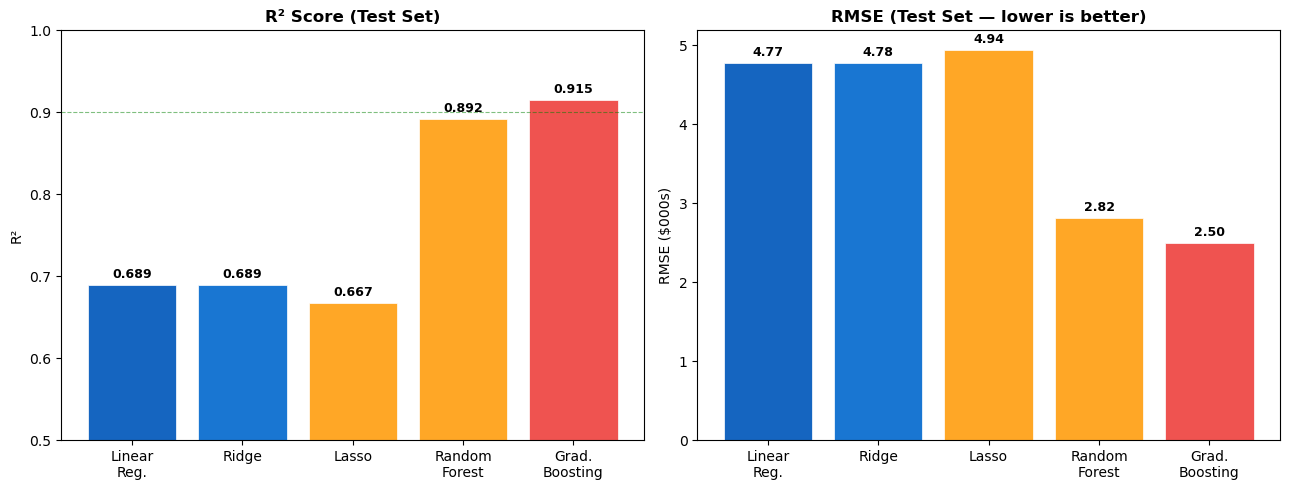

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
short_names = ['Linear\nReg.', 'Ridge', 'Lasso', 'Random\nForest', 'Grad.\nBoosting']
 
bars1 = axes[0].bar(short_names, r2_vals, color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('R² Score (Test Set)', fontweight='bold')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0.5, 1.0)
axes[0].axhline(y=0.9, color='green', linestyle='--', linewidth=0.8, alpha=0.5)
for bar, val in zip(bars1, r2_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
 
bars2 = axes[1].bar(short_names, rmse_vals, color=colors, edgecolor='white', linewidth=0.5)
axes[1].set_title('RMSE (Test Set — lower is better)', fontweight='bold')
axes[1].set_ylabel('RMSE ($000s)')
for bar, val in zip(bars2, rmse_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
 
plt.tight_layout()
#plt.savefig('04_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

***Figure 5: Cross-validation R² with error bars***

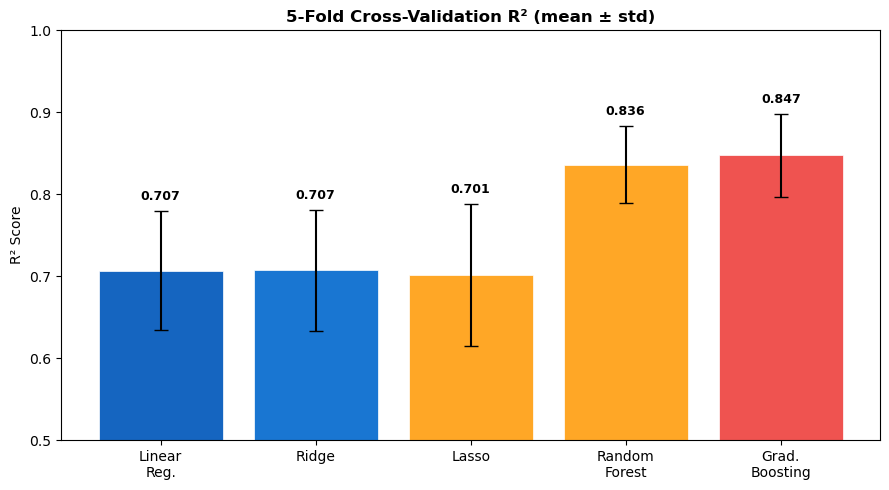

In [28]:
plt.figure(figsize=(9, 5))
x_pos = np.arange(len(model_names))
plt.bar(x_pos, cv_means, yerr=cv_stds, capsize=5,
        color=colors, edgecolor='white', linewidth=0.5, error_kw={'linewidth': 1.5})
plt.xticks(x_pos, short_names)
plt.ylabel('R² Score')
plt.title('5-Fold Cross-Validation R² (mean ± std)', fontweight='bold')
plt.ylim(0.5, 1.0)
for i, (m, s) in enumerate(zip(cv_means, cv_stds)):
    plt.text(i, m + s + 0.01, f'{m:.3f}', ha='center', va='bottom',
             fontsize=9, fontweight='bold')
plt.tight_layout()
#plt.savefig('05_cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()
#print("Saved: 05_cross_validation.png")

# Actual vs Predicted Plots

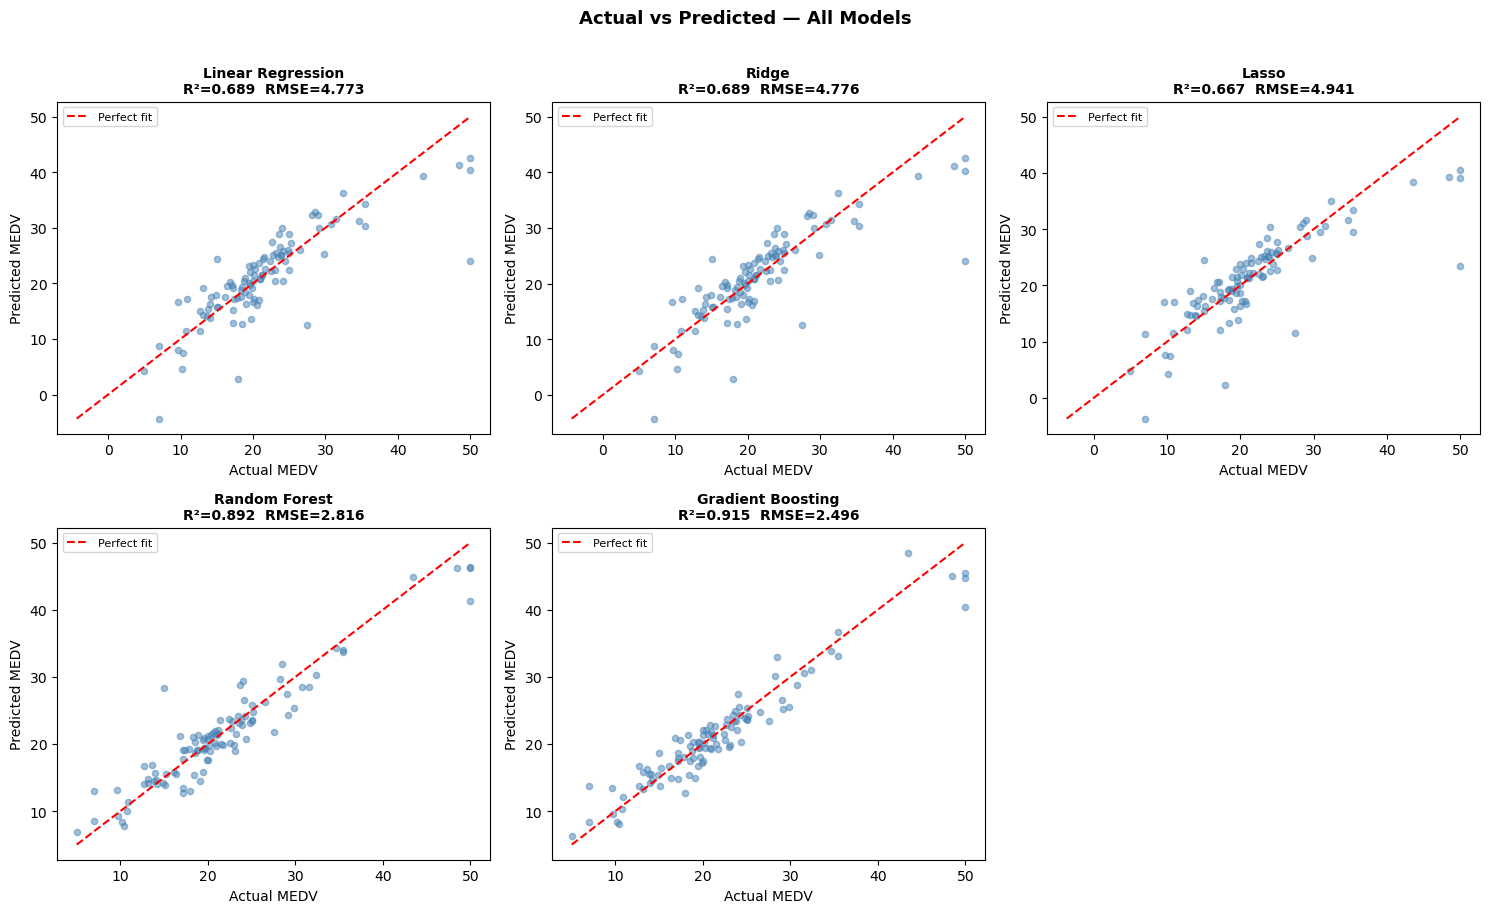

In [65]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
 
for i, (name, res) in enumerate(results.items()):
    ax = axes[i]
    ax.scatter(y_test, res['y_pred'], alpha=0.5, s=20, color='steelblue')
    min_val = min(y_test.min(), res['y_pred'].min())
    max_val = max(y_test.max(), res['y_pred'].max())
    ax.plot([min_val, max_val], [min_val, max_val],
            'r--', linewidth=1.5, label='Perfect fit')
    ax.set_title(f'{name}\nR²={res["R2"]:.3f}  RMSE={res["RMSE"]:.3f}',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Actual MEDV')
    ax.set_ylabel('Predicted MEDV')
    ax.legend(fontsize=8)
 
axes[-1].axis('off')
plt.suptitle('Actual vs Predicted — All Models', fontweight='bold', y=1.01, fontsize=13)
plt.tight_layout()
#plt.savefig('06_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

# Feature Importance

In [29]:
rf_model = models['Random Forest']
gb_model = models['Gradient Boosting']
 
fi_rf = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)
fi_gb = pd.Series(gb_model.feature_importances_, index=X.columns).sort_values(ascending=True)

***Figure 6: Feature importance comparison***

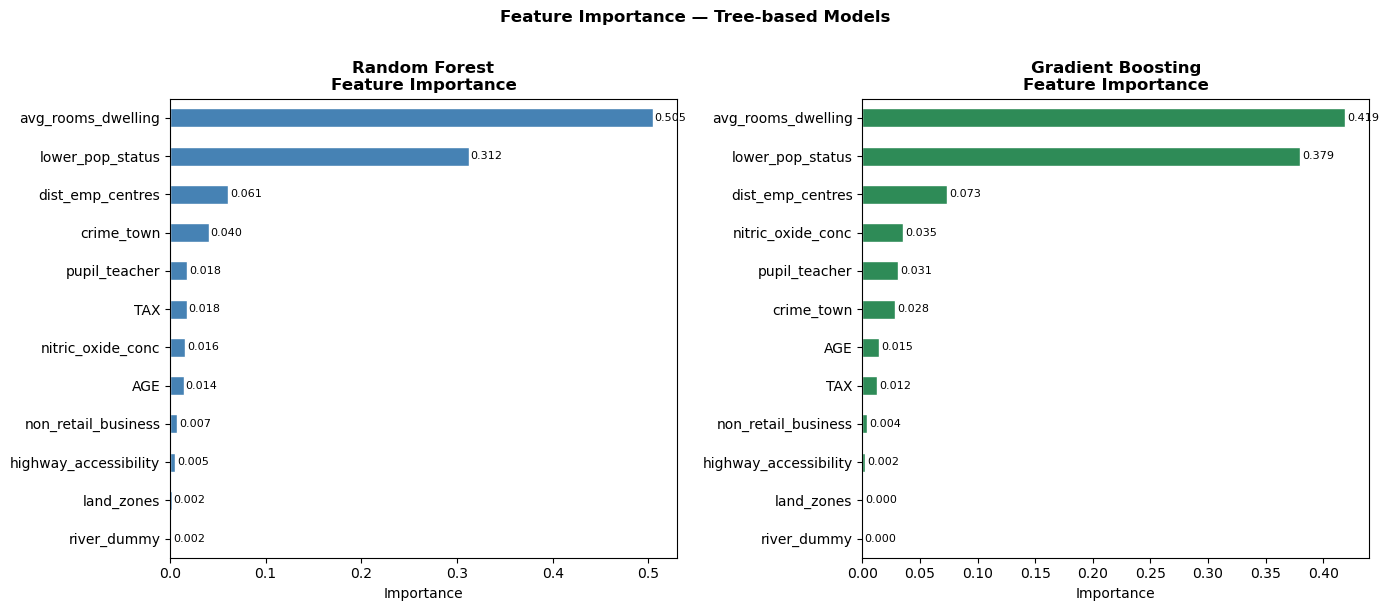

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
fi_rf.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Random Forest\nFeature Importance', fontweight='bold')
axes[0].set_xlabel('Importance')
for i, v in enumerate(fi_rf):
    axes[0].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=8)
 
fi_gb.plot(kind='barh', ax=axes[1], color='seagreen', edgecolor='white')
axes[1].set_title('Gradient Boosting\nFeature Importance', fontweight='bold')
axes[1].set_xlabel('Importance')
for i, v in enumerate(fi_gb):
    axes[1].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=8)
 
plt.suptitle('Feature Importance — Tree-based Models', fontweight='bold', y=1.01)
plt.tight_layout()
#plt.savefig('07_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

***Figure 7: Residual plots for best model***

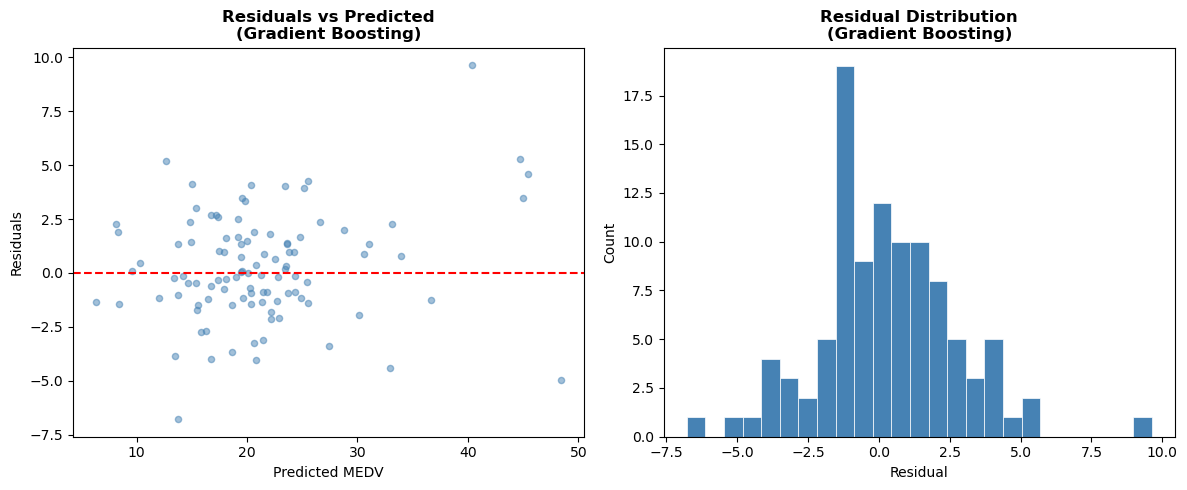

In [33]:
best_pred = results['Gradient Boosting']['y_pred']
residuals  = y_test - best_pred
 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
axes[0].scatter(best_pred, residuals, alpha=0.5, s=20, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('Residuals vs Predicted\n(Gradient Boosting)', fontweight='bold')
axes[0].set_xlabel('Predicted MEDV')
axes[0].set_ylabel('Residuals')
 
axes[1].hist(residuals, bins=25, color='steelblue', edgecolor='white', linewidth=0.5)
axes[1].set_title('Residual Distribution\n(Gradient Boosting)', fontweight='bold')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Count')
 
plt.tight_layout()
#plt.savefig('08_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

# Final Summary

In [34]:
print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
best_model = max(results, key=lambda m: results[m]['R2'])
print(f"Best model  : {best_model}")
print(f"R²          : {results[best_model]['R2']}")
print(f"RMSE        : {results[best_model]['RMSE']} ($000s)")
print(f"MAE         : {results[best_model]['MAE']} ($000s)")
print(f"CV R²       : {results[best_model]['CV_R2_mean']} ± {results[best_model]['CV_R2_std']}")
print("\nTop 3 features (Random Forest importance):")
for feat, imp in fi_rf.sort_values(ascending=False).head(3).items():
    print(f"  {feat:10s}: {imp:.4f}")
print("=" * 60)


FINAL SUMMARY
Best model  : Gradient Boosting
R²          : 0.915
RMSE        : 2.496 ($000s)
MAE         : 1.9045 ($000s)
CV R²       : 0.8473 ± 0.0509

Top 3 features (Random Forest importance):
  avg_rooms_dwelling: 0.5046
  lower_pop_status: 0.3122
  dist_emp_centres: 0.0611
